# HW2: Exploratory Data Analysis - International Coastal Cleanup
**Course:** OEAS 805  
**Dataset:** `International_Coastal_Cleanup.csv` (Norfolk OpenData Portal)

## 1. Background Information
The International Coastal Cleanup dataset documents marine debris collected during cleanup events in Norfolk, Virginia. The goal of this analysis is to inspect dataset dimensions, examine data types and missing values, calculate summary statistics, check for outliers, and explore spatial distribution patterns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Configure plot styles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load dataset
df = pd.read_csv("International_Coastal_Cleanup.csv")

# Standardize column headers (lowercase, no leading/trailing spaces, underscores instead of spaces)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# View the first few rows
df.head()

,area,date,cigarette_butts,"food_wrappers_(candy,_chips,_etc.)",take_out/away_containers_(plastic),take_out/away_containers_(foam),bottle_caps_(plastic),bottle_caps_(metal),lids_(plastic),"straws,_stirrers",...,tampons/tampon_applicators,personal_hygiene_(clean_swell),foam_pieces,glass_pieces,plastic_pieces,total_items_collected,total_pounds_of_litter_collected,number_of_volunteers,volunteer_hours,number_of_miles
0,Ocean View Beach Park,10/27/2023,40,0,3,0,0,0,0,5,...,0,0,0,0,32,85,13,6,6.0,0.50
1,Lakewood Park,10/21/2023,20,64,16,18,107,12,79,31,...,1,0,121,0,121,"1,073",300,12,24.0,1.00
2,Plum Point Park,10/08/2023,7,30,2,6,29,2,7,15,...,0,0,18,11,19,337,90,10,30.0,0.25
3,Lafayette Park & Lavalette Boat Ramp,10/07/2023,220,166,19,55,76,42,24,17,...,0,0,198,76,188,"1,866",65,6,12.0,1.00
4,Barraud Park,10/07/2023,800,486,38,15,142,"2,488",36,149,...,0,0,31,15,13,"5,238",30,28,42.0,2.00


## 1. Dataset Dimensions & Data Types

Understanding the shape and data types of this dataset allows us to verify row/column counts and determine which variables are numeric vs. categorical.

In [2]:
# Dataset dimensions
num_rows, num_cols = df.shape
print(f"Total Samples (Rows): {num_rows}")
print(f"Total Variables (Columns): {num_cols}\n")

# Data types summary
print("--- Data Types Summary ---")
print(df.dtypes.value_counts())

# Detailed info
df.info()

Total Samples (Rows): 77
Total Variables (Columns): 53

--- Data Types Summary ---
int64      39
str        11
float64     3
Name: count, dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 53 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   area                                       77 non-null     str    
 1   date                                       77 non-null     str    
 2   cigarette_butts                            77 non-null     str    
 3   food_wrappers_(candy,_chips,_etc.)         77 non-null     str    
 4   take_out/away_containers_(plastic)         77 non-null     int64  
 5   take_out/away_containers_(foam)            77 non-null     int64  
 6   bottle_caps_(plastic)                      77 non-null     int64  
 7   bottle_caps_(metal)                        77 non-null     str    
 8   lids_(plastic)                  

## 2. Missing Value Analysis

I investigated whether variables contain missing data (`NaN`), and if missing values are concentrated in specific columns.

In [3]:
# Calculate missing values per column
missing_counts = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

# Combine into a summary DataFrame
missing_df = pd.DataFrame({
    'Missing Values': missing_counts,
    'Percentage (%)': missing_percent
}).sort_values(by='Missing Values', ascending=False)

# Filter for columns that actually have missing data
cols_with_missing = missing_df[missing_df['Missing Values'] > 0]

if len(cols_with_missing) > 0:
    print("Columns with missing values:")
    print(cols_with_missing)
    
    # Plot missing values
    plt.figure(figsize=(10, 5))
    cols_with_missing['Percentage (%)'].head(15).plot(kind='bar', color='salmon')
    plt.title("Top Variables with Missing Data (%)")
    plt.ylabel("Percentage Missing")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Good news! This dataset contains 0 missing values across all columns.")

Good news! This dataset contains 0 missing values across all columns.


## 3. Descriptive Statistics & Outliers
I calculated central tendency measures (mean, median, standard deviation) for numerical variables and check for extreme outliers using boxplots and histograms.

In [4]:
# Compute summary statistics
df.describe()

,take_out/away_containers_(plastic),take_out/away_containers_(foam),bottle_caps_(plastic),lids_(plastic),"straws,_stirrers","forks,_knives,_spoons",beverage_bottles_(plastic),beverage_cans,grocery_bags_(plastic),other_plastic_bags,...,toys,other_trash_(clean_swell),condoms,diapers,syringes,tampons/tampon_applicators,foam_pieces,number_of_volunteers,volunteer_hours,number_of_miles
count,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,...,77.000000,77.000000,77.000000,77.000000,77.00000,77.000000,77.000000,77.000000,77.00000,77.000000
mean,18.363636,13.714286,98.337662,23.350649,50.558442,13.909091,68.922078,44.350649,38.961039,36.233766,...,0.168831,18.961039,1.909091,1.259740,0.61039,0.922078,64.441558,18.896104,37.37013,1.530909
std,21.944253,18.943724,148.793093,26.738877,62.141920,20.238825,92.227089,55.825331,59.709922,77.109269,...,0.864544,67.232989,4.205829,3.743073,1.94771,2.113654,128.515767,27.249135,57.04352,1.486711
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,3.000000,1.000000,16.000000,6.000000,11.000000,1.000000,15.000000,6.000000,5.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,5.000000,9.00000,1.000000
50%,8.000000,6.000000,43.000000,13.000000,24.000000,7.000000,34.000000,26.000000,17.000000,10.000000,...,0.000000,0.000000,1.000000,0.000000,0.00000,0.000000,14.000000,11.000000,22.00000,1.000000
75%,31.000000,19.000000,107.000000,33.000000,72.000000,20.000000,70.000000,67.000000,44.000000,34.000000,...,0.000000,1.000000,2.000000,1.000000,1.00000,1.000000,58.000000,22.000000,38.00000,2.000000
max,90.000000,106.000000,780.000000,109.000000,368.000000,136.000000,395.000000,276.000000,326.000000,542.000000,...,7.000000,441.000000,33.000000,24.000000,15.00000,14.000000,750.000000,178.000000,396.00000,10.000000


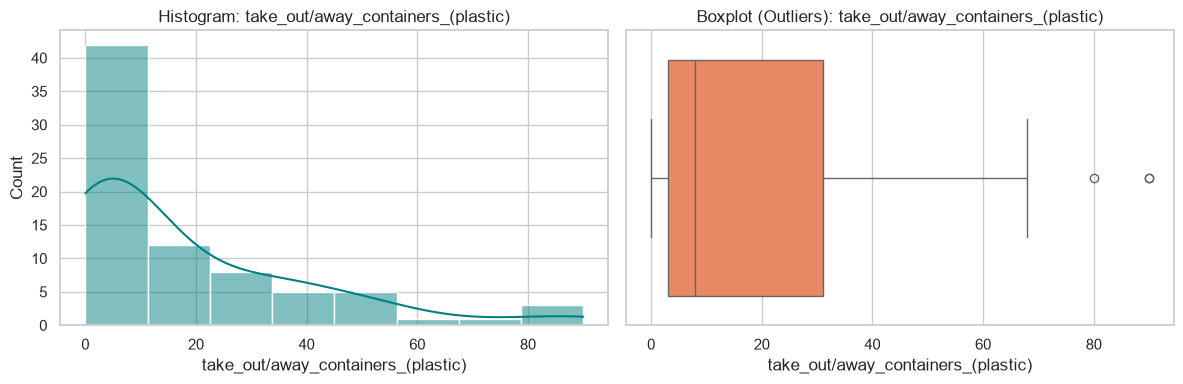

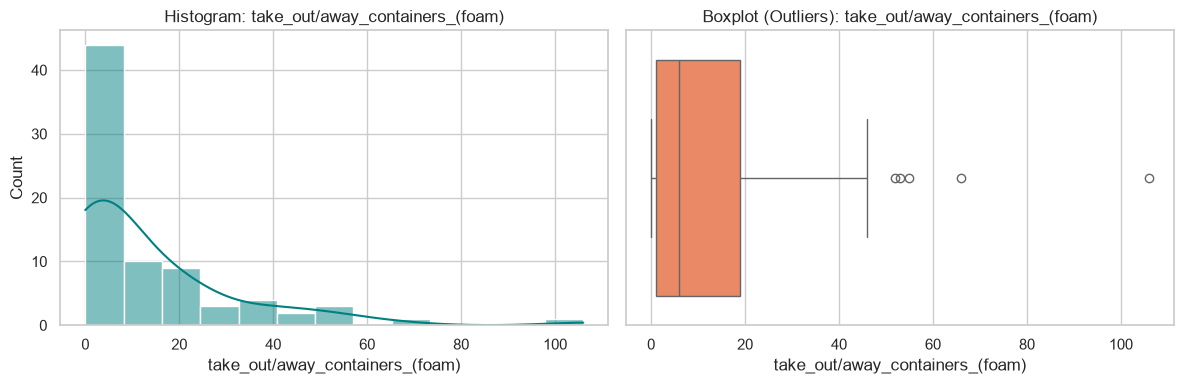

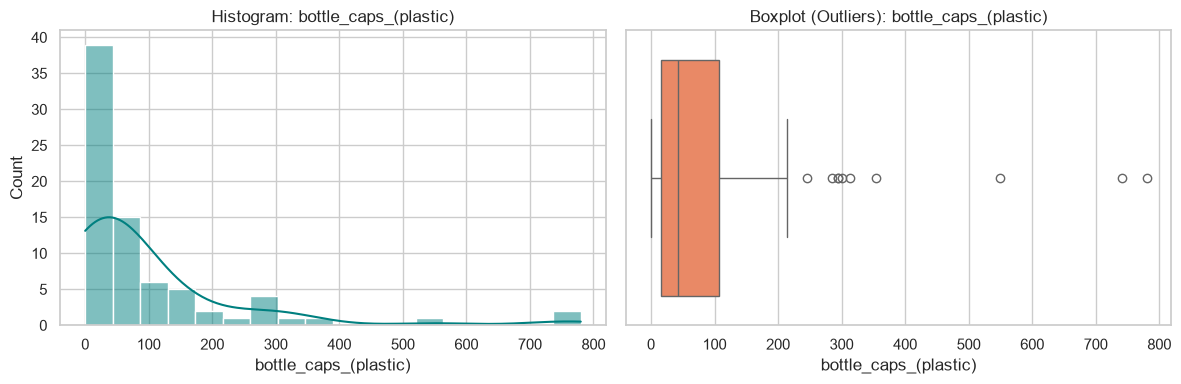

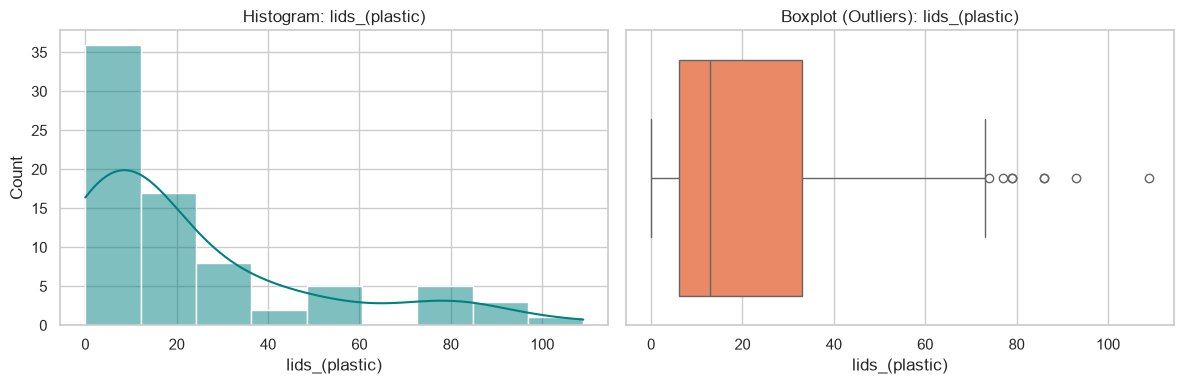

In [5]:
# Identify numeric columns for distribution analysis
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Plot distributions and boxplots for selected key numerical variables
# (Select the first few numeric columns or key debris counts)
sample_cols = numeric_cols[:4] if len(numeric_cols) >= 4 else numeric_cols

for col in sample_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histogram
    sns.histplot(df[col].dropna(), kde=True, ax=axes[0], color='teal')
    axes[0].set_title(f"Histogram: {col}")
    
    # Boxplot (Detect Outliers)
    sns.boxplot(x=df[col].dropna(), ax=axes[1], color='coral')
    axes[1].set_title(f"Boxplot (Outliers): {col}")
    
    plt.tight_layout()
    plt.show()

## 4. Variable Relationships & Correlations

I constructed a correlation matrix heatmap and scatter plots to examine how variables relate to each other (e.g., total trash vs. volunteer count or effort hours).

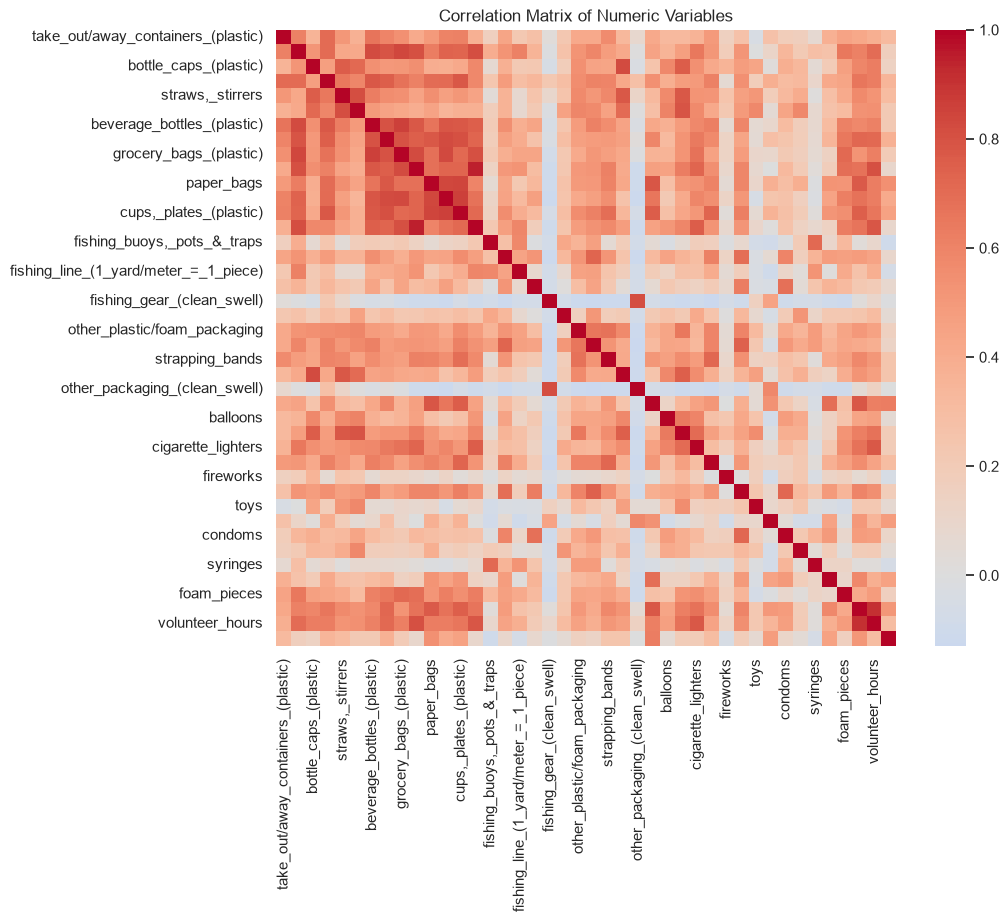

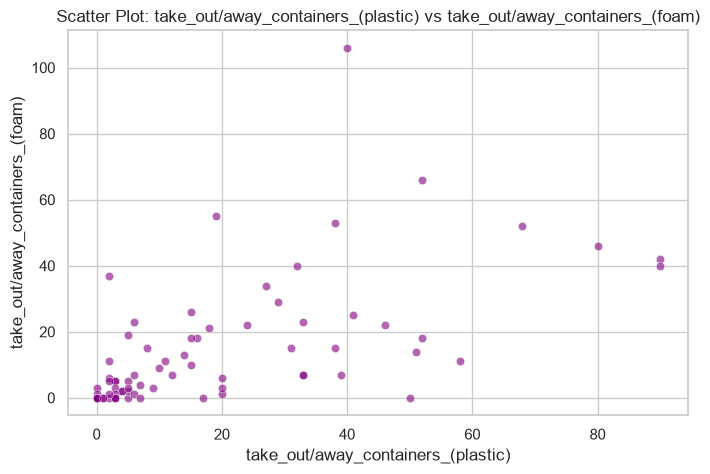

In [6]:
# Calculate correlation matrix for numerical columns
corr_matrix = df[numeric_cols].corr()

# Plot Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title("Correlation Matrix of Numeric Variables")
plt.show()

# Scatter plot example (Adjust column names based on your actual column headers)
# e.g., if columns exist like 'people' vs 'total_bags' or similar:
if len(numeric_cols) >= 2:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x=numeric_cols[0], y=numeric_cols[1], alpha=0.6, color='purple')
    plt.title(f"Scatter Plot: {numeric_cols[0]} vs {numeric_cols[1]}")
    plt.show()

## 5. Spatial Visualization (Cartopy)

Using Cartopy, I projected cleanup event locations onto a global or regional map using the general areas where items were collected previously.

In [7]:
print(df.columns.tolist())

['area', 'date', 'cigarette_butts', 'food_wrappers_(candy,_chips,_etc.)', 'take_out/away_containers_(plastic)', 'take_out/away_containers_(foam)', 'bottle_caps_(plastic)', 'bottle_caps_(metal)', 'lids_(plastic)', 'straws,_stirrers', 'forks,_knives,_spoons', 'beverage_bottles_(plastic)', 'beverage_bottles_(glass)', 'beverage_cans', 'grocery_bags_(plastic)', 'other_plastic_bags', 'paper_bags', 'cups,_plates_(paper)', 'cups,_plates_(plastic)', 'cups,_plates_(foam)', 'fishing_buoys,_pots_&_traps', 'fishing_net_&_pieces', 'fishing_line_(1_yard/meter_=_1_piece)', 'rope_(1_yard/meter_=_1_piece)', 'fishing_gear_(clean_swell)', '6-pack_holders', 'other_plastic/foam_packaging', 'other_plastic_bottles_(oil,_bleach,_etc.)', 'strapping_bands', 'tobacco_packaging/wrap', 'other_packaging_(clean_swell)', 'appliances_(refrigerators,_washers,_etc.)', 'balloons', 'cigar_tips', 'cigarette_lighters', 'construction_materials', 'fireworks', 'tires', 'toys', 'other_trash_(clean_swell)', 'condoms', 'diapers', 

C:\Users\trici\AppData\Local\Temp\ipykernel_12540\1486426738.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=area_summary, x='total_items_collected', y='area', palette='Blues_r')


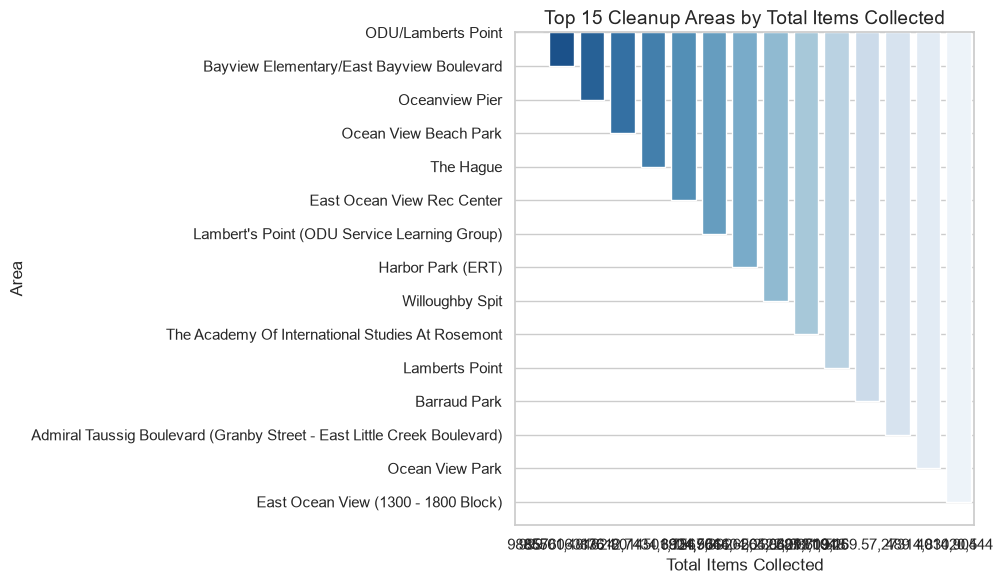

In [8]:
# Aggregate total items collected by regional area
area_summary = df.groupby('area')['total_items_collected'].sum().reset_index()
area_summary = area_summary.sort_values(by='total_items_collected', ascending=False).head(15)

# Visualizing top regional cleanup areas
plt.figure(figsize=(10, 6))
sns.barplot(data=area_summary, x='total_items_collected', y='area', palette='Blues_r')
plt.title("Top 15 Cleanup Areas by Total Items Collected", fontsize=14)
plt.xlabel("Total Items Collected")
plt.ylabel("Area")
plt.tight_layout()
plt.show()